In [24]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
from matplotlib.lines import Line2D

with open("../results/association_rules/readable_rules.pkl", "rb") as f:
    readable_rules = pickle.load(f)

with open("../results/frequent_itemsets/frequent_itemsets_fp.pkl", "rb") as f:
    frequent_itemsets_fp = pickle.load(f)

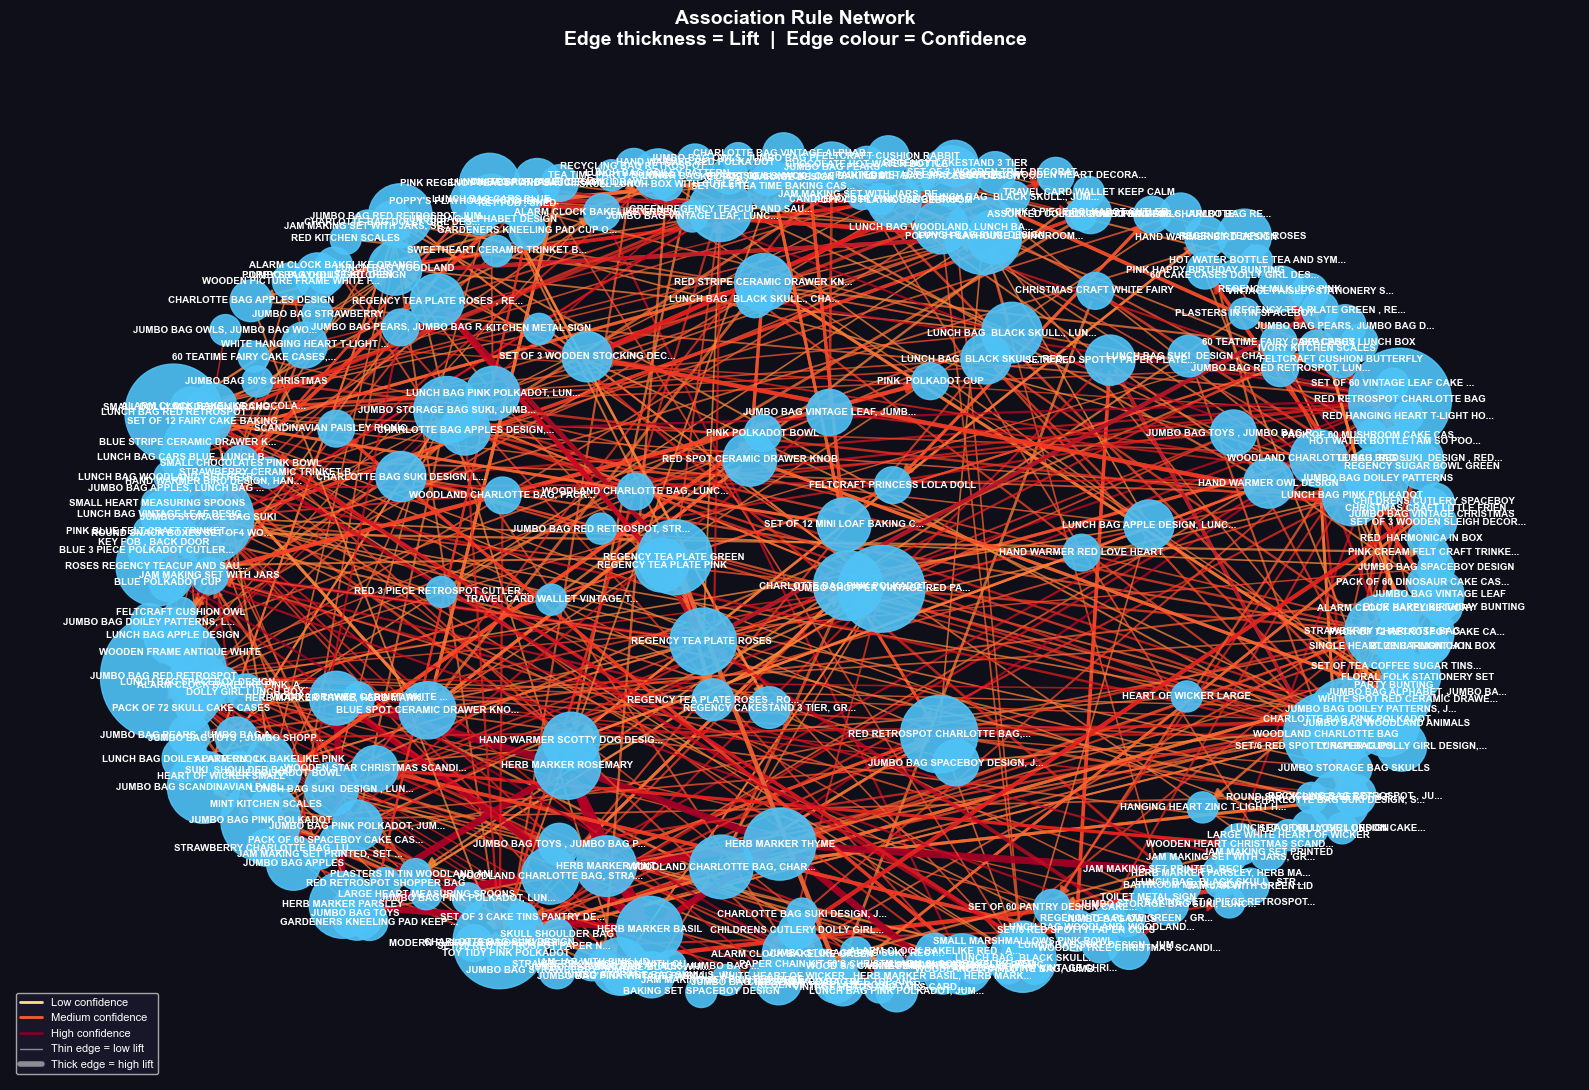

In [25]:
# Filter to strong rules only — keeps the graph readable
net_rules = readable_rules[
    (readable_rules["confidence"] >= 0.5) &
    (readable_rules["lift"] >= 3)
    ].copy()

# Shorten long product names for node labels
def shorten(name, max_len=28):
    return name if len(name) <= max_len else name[:max_len] + "..."

net_rules["ant_short"] = net_rules["antecedents_description"].apply(shorten)
net_rules["con_short"] = net_rules["consequents_description"].apply(shorten)

# Build directed graph
G = nx.DiGraph()

for _, row in net_rules.iterrows():
    G.add_edge(
        row["ant_short"],
        row["con_short"],
        weight=row["lift"],
        confidence=row["confidence"]
    )

# Layout
pos = nx.spring_layout(G, seed=42, k=2.5)

# Edge properties
edges      = G.edges(data=True)
lifts      = [d["weight"] for _, _, d in edges]
confs      = [d["confidence"] for _, _, d in edges]

lift_min, lift_max = min(lifts), max(lifts)
edge_widths = [1 + 4 * (l - lift_min) / (lift_max - lift_min + 1e-9) for l in lifts]
edge_colors = [plt.cm.YlOrRd(c) for c in confs]

# Node size by degree
degrees    = dict(G.degree())
node_sizes = [300 + 200 * degrees[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 11))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.75,
    arrows=True,
    arrowsize=15,
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#4fc3f7",
    alpha=0.9,
    ax=ax
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=7,
    font_color="white",
    font_weight="bold",
    ax=ax
)

# Legend
legend_elements = [
    Line2D([0], [0], color=plt.cm.YlOrRd(0.2), lw=2, label="Low confidence"),
    Line2D([0], [0], color=plt.cm.YlOrRd(0.6), lw=2, label="Medium confidence"),
    Line2D([0], [0], color=plt.cm.YlOrRd(1.0), lw=2, label="High confidence"),
    Line2D([0], [0], lw=1, label="Thin edge = low lift",  color="white", alpha=0.5),
    Line2D([0], [0], lw=4, label="Thick edge = high lift", color="white", alpha=0.5),
]
ax.legend(
    handles=legend_elements,
    loc="lower left",
    facecolor="#1a1a2e",
    labelcolor="white",
    fontsize=8,
    framealpha=0.8
)

ax.set_title(
    "Association Rule Network\nEdge thickness = Lift  |  Edge colour = Confidence",
    color="white", fontsize=14, fontweight="bold", pad=15
)
ax.axis("off")
plt.tight_layout()
plt.savefig("../images/network_graph.png", dpi=180, bbox_inches="tight")
plt.show()

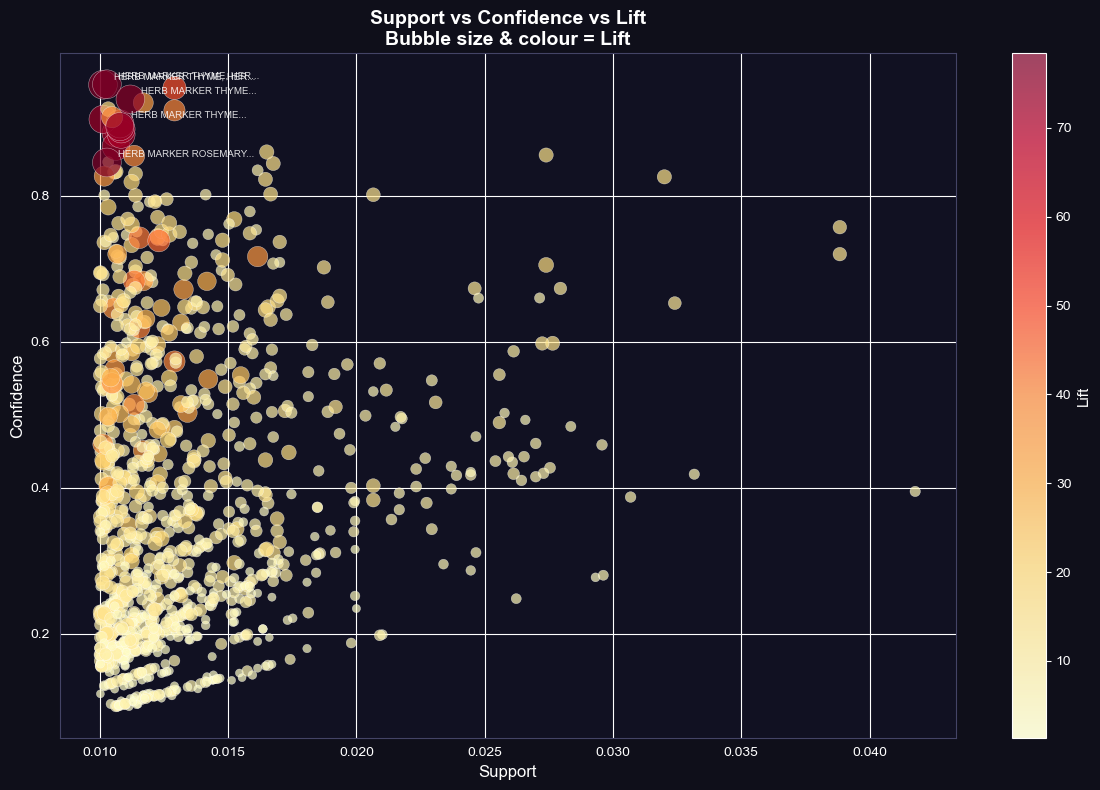

In [28]:
# Sample for readability
bubble_df = readable_rules.sample(
    frac=0.3,
    random_state=42
).copy()

# ============================================
# Normalize lift for bubble size
# ============================================

lift_norm = (
        (bubble_df["lift"] - bubble_df["lift"].min()) /
        (bubble_df["lift"].max() - bubble_df["lift"].min() + 1e-9)
)

bubble_sizes = 30 + lift_norm * 400


# ============================================
# Plot
# ============================================

fig, ax = plt.subplots(
    figsize=(12, 8)
)

fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#111122")


sc = ax.scatter(
    bubble_df["support"],
    bubble_df["confidence"],
    s=bubble_sizes,
    c=bubble_df["lift"],
    cmap="YlOrRd",
    alpha=0.70,
    edgecolors="white",
    linewidths=0.3
)


# ============================================
# Colourbar
# ============================================

cbar = plt.colorbar(
    sc,
    ax=ax
)

cbar.set_label(
    "Lift",
    color="white",
    fontsize=11
)

cbar.ax.yaxis.set_tick_params(
    color="white"
)

plt.setp(
    cbar.ax.yaxis.get_ticklabels(),
    color="white"
)


# ============================================
# Annotate top 5 lift rules
# ============================================

top_rules = bubble_df.nlargest(
    5,
    "lift"
)

for _, row in top_rules.iterrows():

    label = (
            str(row["antecedents_description"])[:22]
            + "..."
    )

    ax.annotate(
        label,
        xy=(
            row["support"],
            row["confidence"]
        ),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=7,
        color="white",
        alpha=0.85
    )


# ============================================
# Labels
# ============================================

ax.set_xlabel(
    "Support",
    color="white",
    fontsize=12
)

ax.set_ylabel(
    "Confidence",
    color="white",
    fontsize=12
)


ax.set_title(
    "Support vs Confidence vs Lift\n"
    "Bubble size & colour = Lift",
    color="white",
    fontsize=14,
    fontweight="bold"
)


# ============================================
# Styling
# ============================================

ax.tick_params(
    colors="white"
)

for spine in ax.spines.values():
    spine.set_edgecolor("#444466")


plt.tight_layout()


# ============================================
# Save
# ============================================

plt.savefig(
    "../images/bubble_chart.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

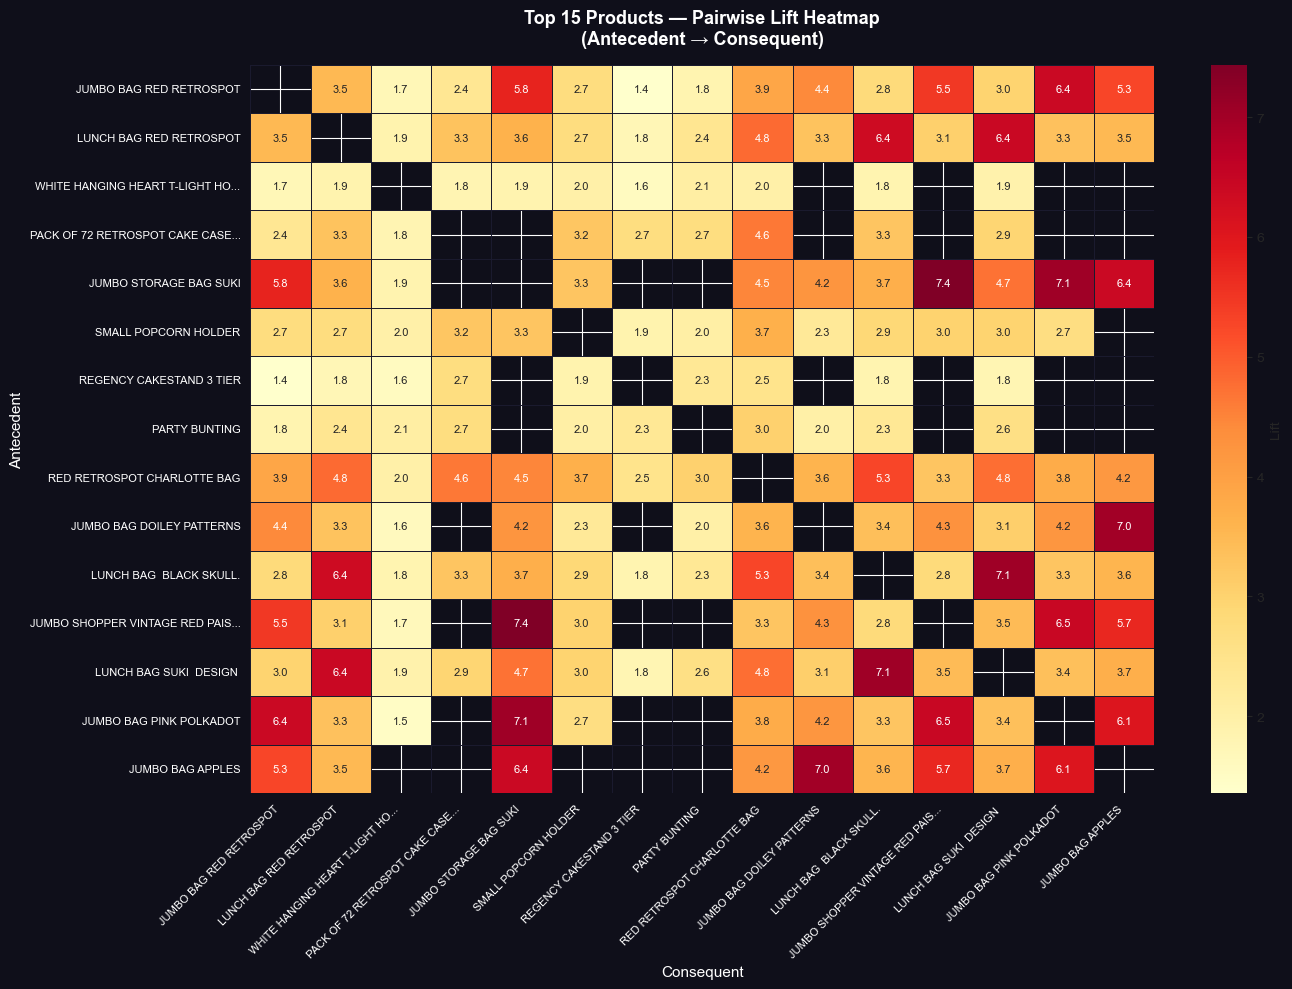

In [27]:
# Take top N products by how often they appear in rules
top_n = 15

# Get all unique antecedents and consequents (single-item only for clean heatmap)
single_ant = readable_rules[
    readable_rules["antecedents"].apply(len) == 1
    ].copy()
single_con = single_ant[
    single_ant["consequents"].apply(len) == 1
    ].copy()

single_con["ant_label"] = single_con["antecedents_description"].apply(
    lambda x: x[:30] + "..." if len(x) > 30 else x
)
single_con["con_label"] = single_con["consequents_description"].apply(
    lambda x: x[:30] + "..." if len(x) > 30 else x
)

# Find top products by rule frequency
top_products = (
    pd.concat([single_con["ant_label"], single_con["con_label"]])
    .value_counts()
    .head(top_n)
    .index
    .tolist()
)

# Filter to top products only
filtered = single_con[
    single_con["ant_label"].isin(top_products) &
    single_con["con_label"].isin(top_products)
    ]

# Pivot to matrix
lift_matrix = filtered.pivot_table(
    index="ant_label",
    columns="con_label",
    values="lift",
    aggfunc="max"
)

# Reindex to keep top_products order
lift_matrix = lift_matrix.reindex(
    index=[p for p in top_products if p in lift_matrix.index],
    columns=[p for p in top_products if p in lift_matrix.columns]
)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

sns.heatmap(
    lift_matrix,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    linecolor="#1a1a2e",
    cbar_kws={"label": "Lift"},
    mask=lift_matrix.isna(),
    annot_kws={"size": 8}
)

ax.set_title(
    f"Top {top_n} Products — Pairwise Lift Heatmap\n(Antecedent → Consequent)",
    color="white", fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Consequent", color="white", fontsize=11)
ax.set_ylabel("Antecedent", color="white", fontsize=11)
ax.tick_params(colors="white", labelsize=8)
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/heatmap_lift.png", dpi=180, bbox_inches="tight")
plt.show()